In [5]:
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, ConfusionMatrixDisplay
from sklearn.manifold import TSNE


In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 


In [7]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [8]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [9]:
X_train = X_train.reshape(len(X_train), np.prod(X_train.shape[1:]))
X_test = X_test.reshape(len(X_test), np.prod(X_test.shape[1:]))
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [10]:
input_img= Input(shape=(784,))
encoded = Dense(units=8, activation='relu')(input_img)
decoded = Dense(units=784, activation='sigmoid')(encoded)

In [12]:
autoencoder=Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │         7,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,336 (52.09 KB)

 Trainable params: 13,336 (52.09 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
encoder = Model(input_img, encoded)
encoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         6,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,280 (24.53 KB)

 Trainable params: 6,280 (24.53 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
autoencoder.fit(X_train, X_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(X_test, X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0053 - loss: 0.4584 - val_accuracy: 0.0184 - val_loss: 0.2509
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0168 - loss: 0.2392 - val_accuracy: 0.0144 - val_loss: 0.2069
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0167 - loss: 0.2026 - val_accuracy: 0.0139 - val_loss: 0.1888
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0138 - loss: 0.1879 - val_accuracy: 0.0114 - val_loss: 0.1821
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0117 - loss: 0.1826 - val_accuracy: 0.0113 - val_loss: 0.1792
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0110 - loss: 0.1796 - val_accuracy: 0.0109 - val_loss: 0.1773
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0100 - loss: 0.1784 - val_accuracy: 0.0095 - val_loss: 0.1755
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0105 - loss: 0.1763 - val_accuracy: 0.

In [24]:
encoded_imgs = encoder.predict(X_test)
predicted = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 236us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step


In [25]:
encoded_imgs.shape

(10000, 8)

In [26]:
predicted.shape

(10000, 784)

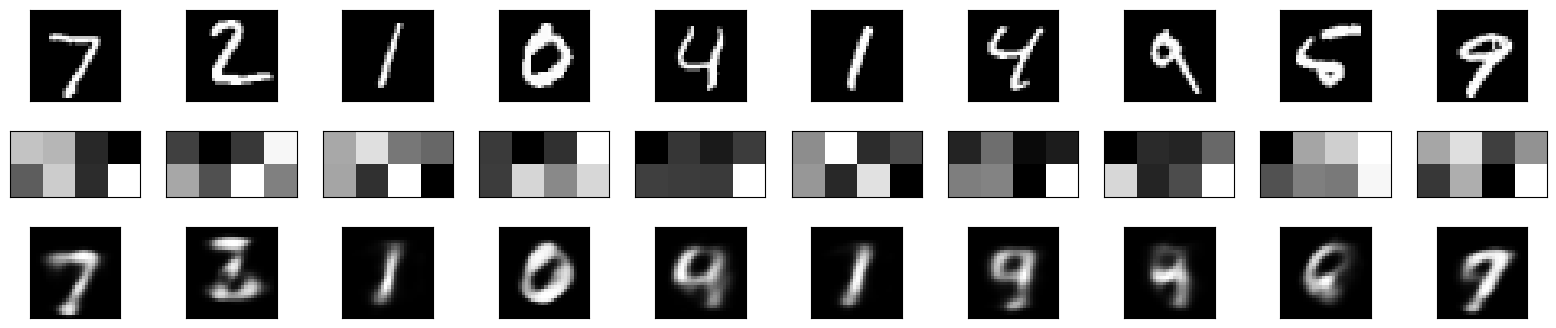

In [27]:
plt.figure(figsize=(40, 4))
for i in range(10):
    # display original
    ax = plt.subplot(3, 20, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display encoded image
    ax = plt.subplot(3, 20, i + 1 + 20)
    plt.imshow(encoded_imgs[i].reshape(2,4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # display reconstruction
    ax = plt.subplot(3, 20, 2*20 +i+ 1)
    plt.imshow(predicted[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)



plt.show()

In [28]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 211us/step


In [29]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(60000, 8)
(10000, 8)


# Processo de Classificaçao com Random Forest

In [30]:
modelRf = RandomForestClassifier()
modelRf.fit(X_train_encoded, y_train)
y_pred = modelRf.predict(X_test_encoded)

In [31]:
print(classification_report(y_test, y_pred))

print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       980
           1       0.97      0.98      0.98      1135
           2       0.91      0.92      0.91      1032
           3       0.86      0.89      0.88      1010
           4       0.86      0.85      0.85       982
           5       0.86      0.83      0.85       892
           6       0.92      0.94      0.93       958
           7       0.91      0.91      0.91      1028
           8       0.86      0.79      0.83       974
           9       0.80      0.80      0.80      1009

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

0.889


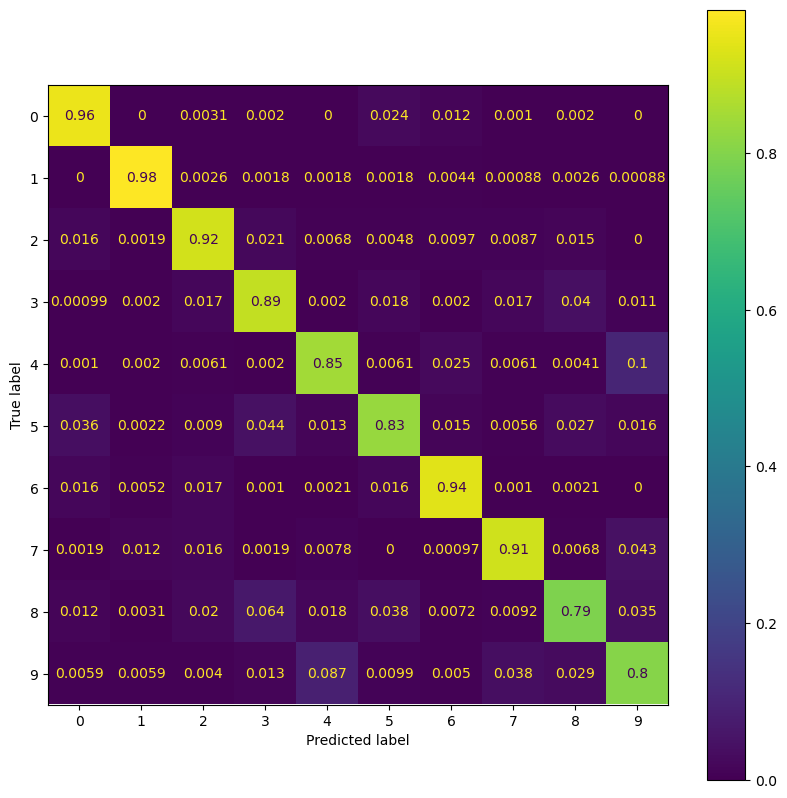

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))

cm = confusion_matrix(y_test, y_pred, labels=modelRf.classes_, normalize = 'true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=modelRf.classes_)

disp.plot(ax = ax)
plt.show()

# Exemplo de Data Visualization a partir da camada Coded do Autoencoder

In [33]:
tsne = TSNE(n_iter=2000)
X_embedded_tsne = tsne.fit_transform(X_test_encoded)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


<Axes: >

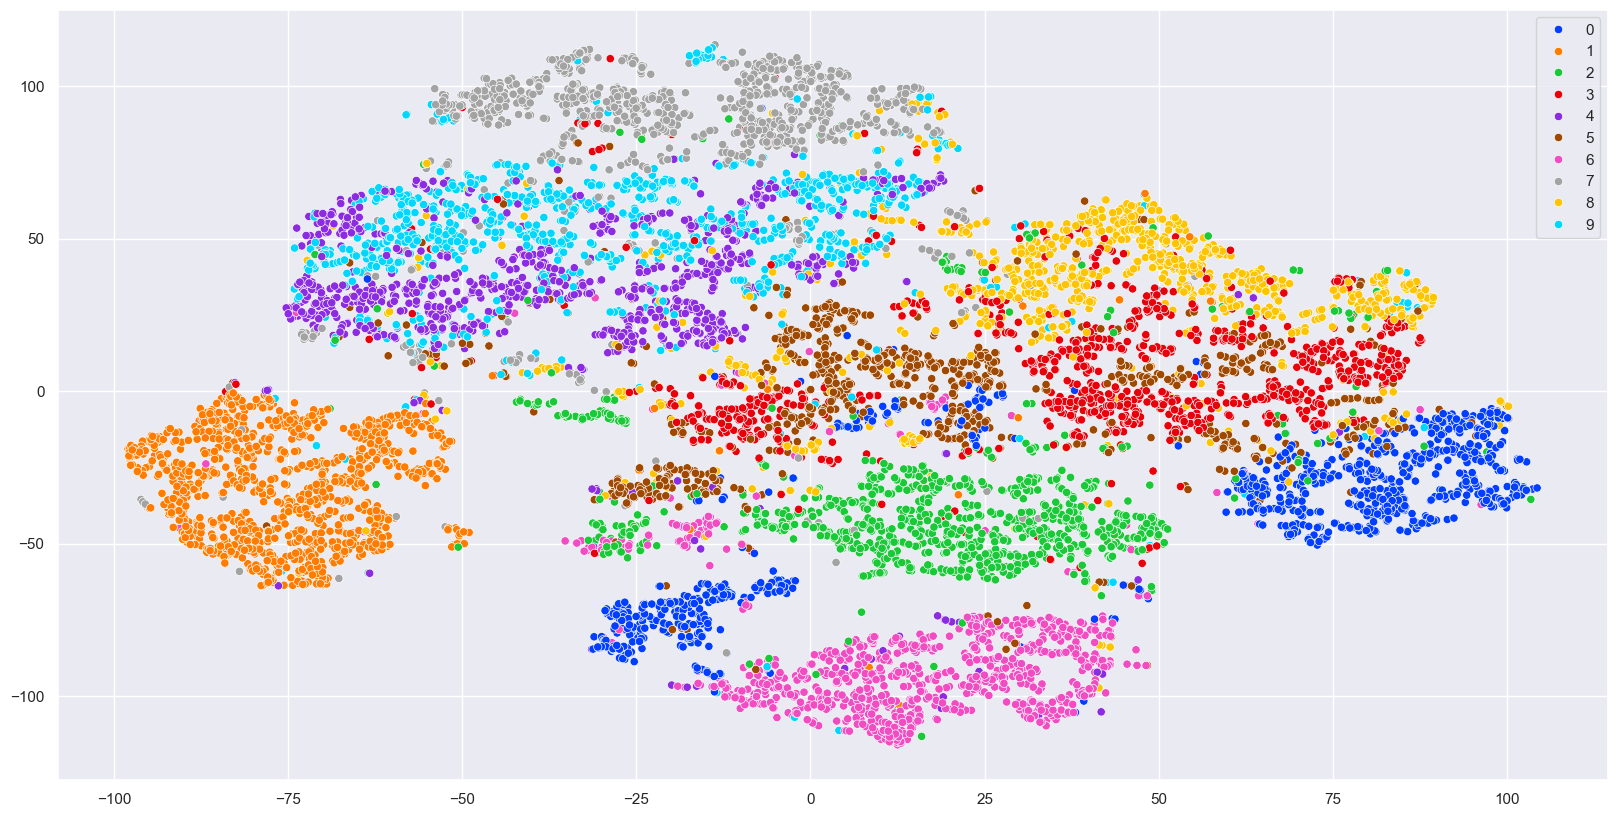

In [34]:
sns.set(rc={'figure.figsize':(20,10)})
palette = sns.color_palette("bright", 10)
sns.scatterplot(x = X_embedded_tsne[:,0], y = X_embedded_tsne[:,1], hue=y_test, legend='full', palette=palette)

##PCA

In [35]:
from sklearn.decomposition import PCA

In [36]:
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)

In [37]:
modelRf = RandomForestClassifier()
modelRf.fit(X_train_pca, y_train)
y_pred = modelRf.predict(X_test_pca)

In [38]:
print(classification_report(y_test, y_pred))

print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       980
           1       0.97      0.99      0.98      1135
           2       0.92      0.93      0.92      1032
           3       0.89      0.90      0.89      1010
           4       0.87      0.86      0.86       982
           5       0.86      0.85      0.86       892
           6       0.93      0.93      0.93       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.83      0.85       974
           9       0.83      0.83      0.83      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

0.9008


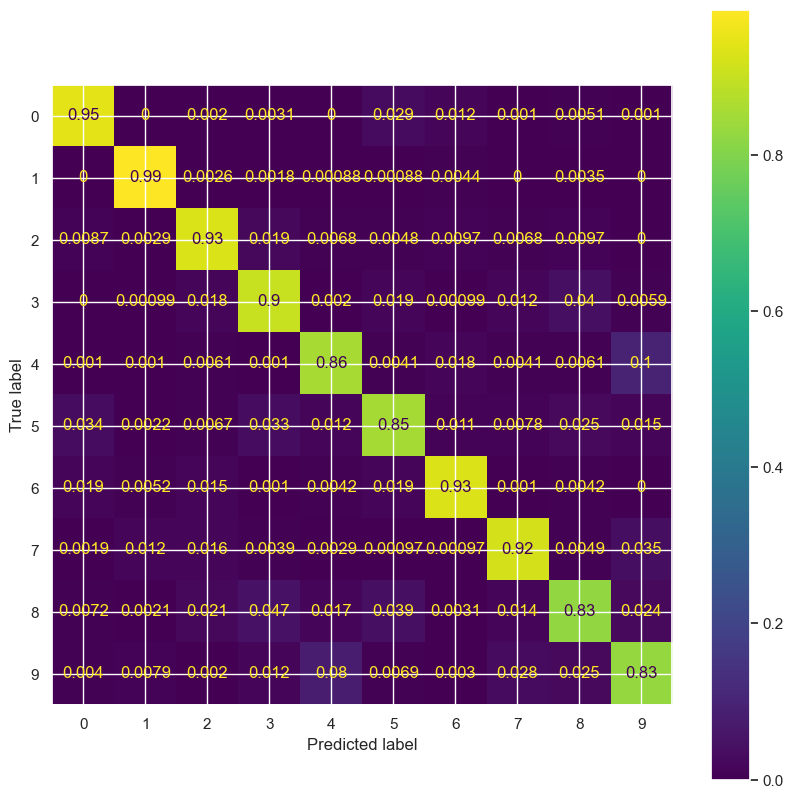

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))

cm = confusion_matrix(y_test, y_pred, labels=modelRf.classes_, normalize = 'true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=modelRf.classes_)

disp.plot(ax = ax)
plt.show()